# 01 — Feature & Relationship EDA


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (13, 5), 'figure.dpi': 110})

MONTHS   = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
REAL_M   = [9, 10, 11]   # Sep, Oct, Nov — real CEB data months

CEB_PATH   = Path('../../processed/MASTER_DATASET_ALL_10TRANSFORMERS.csv')
FINAL_PATH = Path('../data/processed/final.csv')

raw   = pd.read_csv(CEB_PATH)
solar = raw[raw['HAS_SOLAR']==1].copy()
df    = pd.read_csv(FINAL_PATH)

print(f"final.csv   : {len(df):,} records  |  {df.shape[1]} columns")
print(f"Accounts    : {df['ACCOUNT_NO'].nunique() if 'ACCOUNT_NO' in df.columns else 'N/A'}")
print(f"Months      : {sorted(df['Month'].unique())}")
df.head()

final.csv   : 2,676 records  |  19 columns
Accounts    : 223
Months      : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


,ACCOUNT_NO,Month,EXPORT_kWh,INV_CAPACITY,Solar_Irradiance_GHI,Temperature,Humidity,Precipitation,Wind_Speed,Temp_Efficiency,Temp_Range,GHI_Adjusted,Cloud_Factor,Month_Sin,Month_Cos,Days_In_Month,Expected_Generation,Physics_Pred,Efficiency
0,703376806,1,503.75,5.0,5.6150,25.07,78.30,1.03,3.92,1.000,10.72,5.62,0.91,0.500,0.866,31,696.26,139.25,100.750
1,703376806,2,442.38,5.0,6.4942,26.47,75.66,2.40,2.92,0.993,11.70,6.45,0.95,0.866,0.500,28,727.35,145.47,88.476
2,703376806,3,487.08,5.0,5.9909,27.42,76.90,3.98,2.33,0.988,9.15,5.92,0.85,1.000,0.000,31,742.87,148.57,97.416
3,703376806,4,435.40,5.0,5.9580,27.70,80.60,8.83,2.23,0.986,8.86,5.87,0.84,0.866,-0.500,30,714.96,142.99,87.080
4,703376806,5,468.26,5.0,4.5674,26.95,87.01,13.33,4.45,0.990,6.33,4.52,0.67,0.500,-0.866,31,566.36,113.27,93.652


## 1. Target Variable Justification — Why Efficiency (EXPORT_kWh / INV_CAPACITY)?

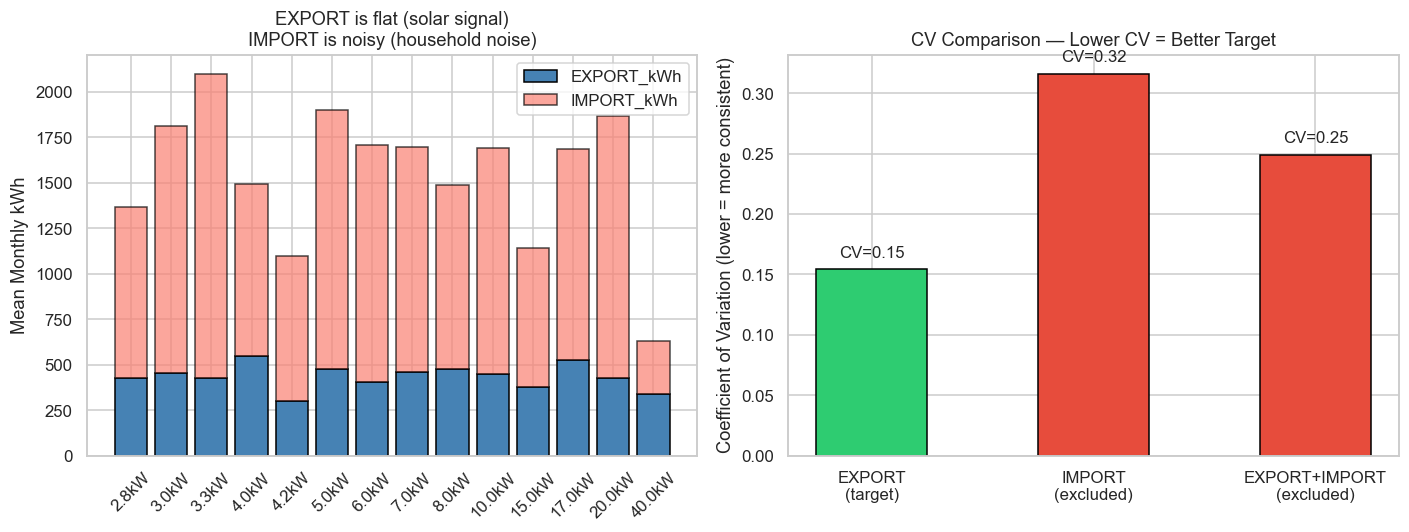

EXPORT CV = 0.15  <- stable solar-correlated signal
IMPORT CV = 0.32  <- noisy household-driven signal  
EXP+IMP CV= 0.25  <- dominated by IMPORT noise      

-> EXPORT_kWh / INV_CAPACITY (Efficiency) is the correct target.


In [20]:
by_cap = solar.groupby('INV_CAPACITY')[['EXPORT_kWh','IMPORT_kWh']].mean().round(1)
by_cap['EXP+IMP'] = (by_cap['EXPORT_kWh'] + by_cap['IMPORT_kWh']).round(1)

exp_cv = by_cap['EXPORT_kWh'].std() / by_cap['EXPORT_kWh'].mean()
imp_cv = by_cap['IMPORT_kWh'].std() / by_cap['IMPORT_kWh'].mean()
tot_cv = by_cap['EXP+IMP'].std()    / by_cap['EXP+IMP'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
caps = by_cap.index.tolist()

# Stacked bar
axes[0].bar(range(len(caps)), by_cap['EXPORT_kWh'], color='steelblue', edgecolor='black', label='EXPORT_kWh')
axes[0].bar(range(len(caps)), by_cap['IMPORT_kWh'], bottom=by_cap['EXPORT_kWh'],
            color='salmon', edgecolor='black', alpha=0.7, label='IMPORT_kWh')
axes[0].set_xticks(range(len(caps))); axes[0].set_xticklabels([f'{c}kW' for c in caps], rotation=45)
axes[0].set_ylabel('Mean Monthly kWh')
axes[0].set_title('EXPORT is flat (solar signal)\nIMPORT is noisy (household noise)')
axes[0].legend()

# CV comparison bar
cv_vals   = [exp_cv, imp_cv, tot_cv]
cv_labels = ['EXPORT\n(target)', 'IMPORT\n(excluded)', 'EXPORT+IMPORT\n(excluded)']
cv_colors = ['#2ecc71', '#e74c3c', '#e74c3c']
bars = axes[1].bar(cv_labels, cv_vals, color=cv_colors, edgecolor='black', width=0.5)
for bar, v in zip(bars, cv_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01, f'CV={v:.2f}', ha='center', fontsize=11)
axes[1].set_ylabel('Coefficient of Variation (lower = more consistent)')
axes[1].set_title('CV Comparison — Lower CV = Better Target')
plt.tight_layout()
plt.savefig('figures/01_target_justification.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"EXPORT CV = {exp_cv:.2f}  <- stable solar-correlated signal")
print(f"IMPORT CV = {imp_cv:.2f}  <- noisy household-driven signal  ")
print(f"EXP+IMP CV= {tot_cv:.2f}  <- dominated by IMPORT noise      ")
print("\n-> EXPORT_kWh / INV_CAPACITY (Efficiency) is the correct target.")

## 2. Efficiency Distribution

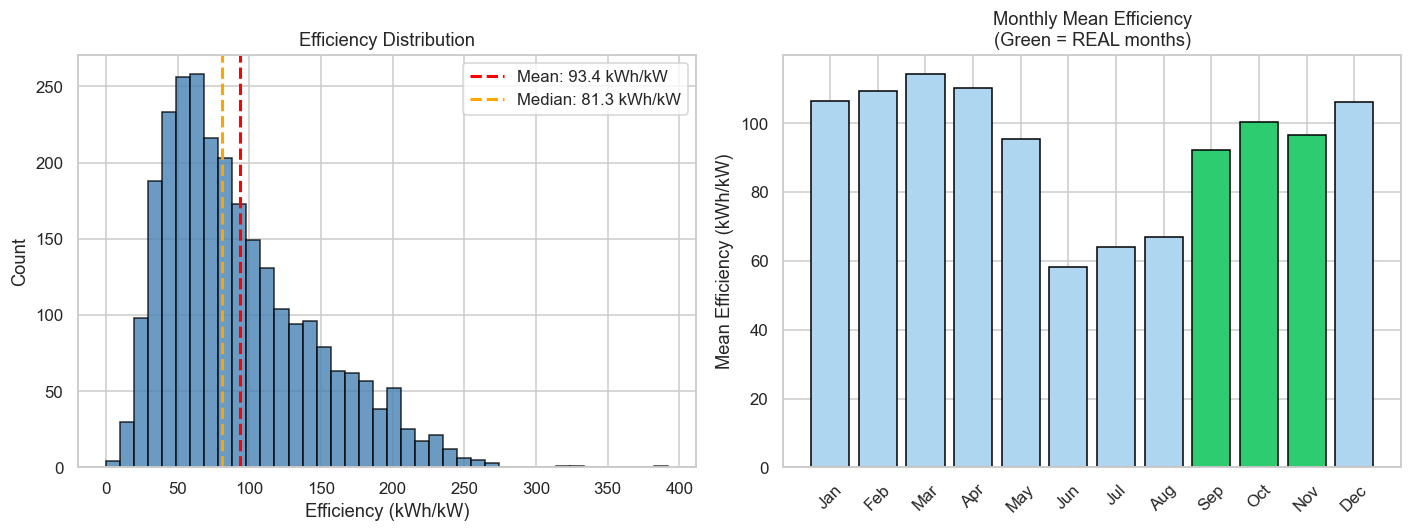

count    2676.000
mean       93.398
std        52.391
min         0.000
25%        53.533
50%        81.286
75%       123.752
max       392.036
Name: Efficiency, dtype: float64

Zero/negative: 2


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(df['Efficiency'], bins=40, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(df['Efficiency'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {df['Efficiency'].mean():.1f} kWh/kW")
axes[0].axvline(df['Efficiency'].median(), color='orange', linestyle='--', linewidth=2,
                label=f"Median: {df['Efficiency'].median():.1f} kWh/kW")
axes[0].set_xlabel('Efficiency (kWh/kW)'); axes[0].set_ylabel('Count')
axes[0].set_title('Efficiency Distribution')
axes[0].legend()

# Monthly mean
monthly_eff = df.groupby('Month')['Efficiency'].mean()
real_colors = ['#2ecc71' if m in REAL_M else '#aed6f1' for m in monthly_eff.index]
axes[1].bar(monthly_eff.index, monthly_eff.values, color=real_colors, edgecolor='black')
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(MONTHS, rotation=45)
axes[1].set_ylabel('Mean Efficiency (kWh/kW)')
axes[1].set_title('Monthly Mean Efficiency\n(Green = REAL months)')
plt.tight_layout()
plt.savefig('figures/01_efficiency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['Efficiency'].describe().round(3))
print(f"\nZero/negative: {(df['Efficiency']<=0).sum()}")

## 2b. Efficiency Distribution by Month — Why 'Month' Is a Necessary Feature

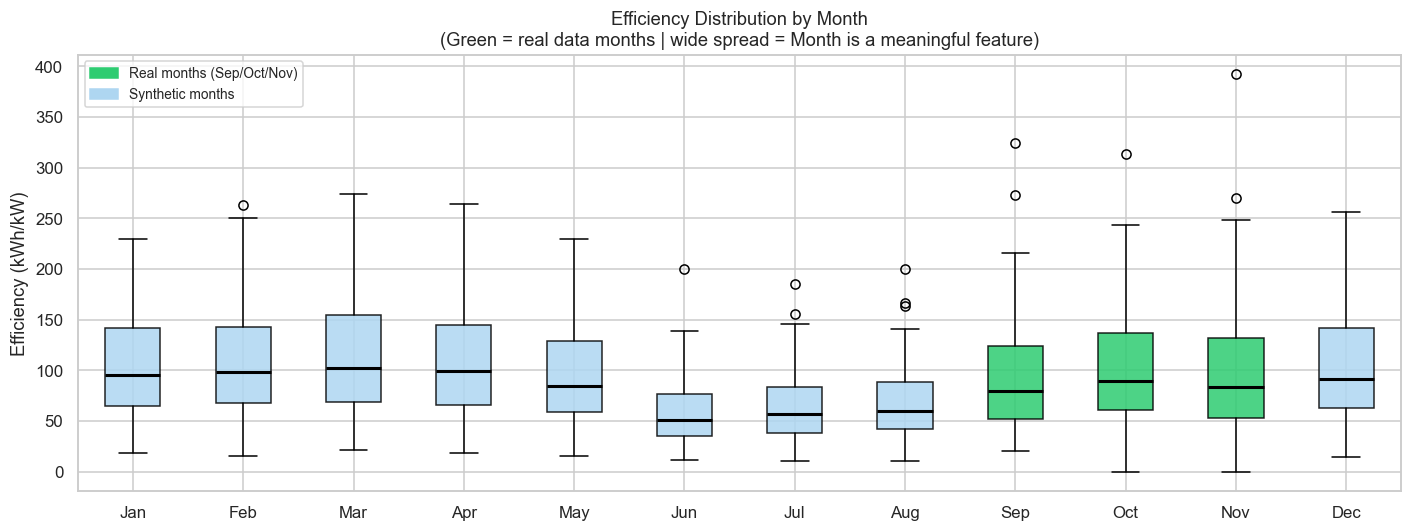

Monthly range: 58.2 to 114.2 kWh/kW
Spread: 56.0 kWh/kW (60.0% of mean)
Month explains significant variance -> necessary model feature.


In [22]:
fig, ax = plt.subplots(figsize=(13, 5))

monthly_data = [df[df['Month']==m]['Efficiency'].values for m in range(1,13)]
real_m_set   = set(REAL_M)

bp = ax.boxplot(monthly_data, labels=MONTHS, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))

for patch, m in zip(bp['boxes'], range(1,13)):
    patch.set_facecolor('#2ecc71' if m in real_m_set else '#aed6f1')
    patch.set_alpha(0.85)

ax.set_ylabel('Efficiency (kWh/kW)')
ax.set_title('Efficiency Distribution by Month\n'
             '(Green = real data months | wide spread = Month is a meaningful feature)')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2ecc71', label='Real months (Sep/Oct/Nov)'),
    Patch(color='#aed6f1', label='Synthetic months')
], fontsize=9)

plt.tight_layout()
plt.savefig('figures/01_efficiency_by_month_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

monthly_means = df.groupby('Month')['Efficiency'].mean()
rng = monthly_means.max() - monthly_means.min()
print(f'Monthly range: {monthly_means.min():.1f} to {monthly_means.max():.1f} kWh/kW')
print(f'Spread: {rng:.1f} kWh/kW ({rng/monthly_means.mean()*100:.1f}% of mean)')
print('Month explains significant variance -> necessary model feature.')


## 3. Filtered Correlation Heatmap — Real Data Only (Sep/Oct/Nov)

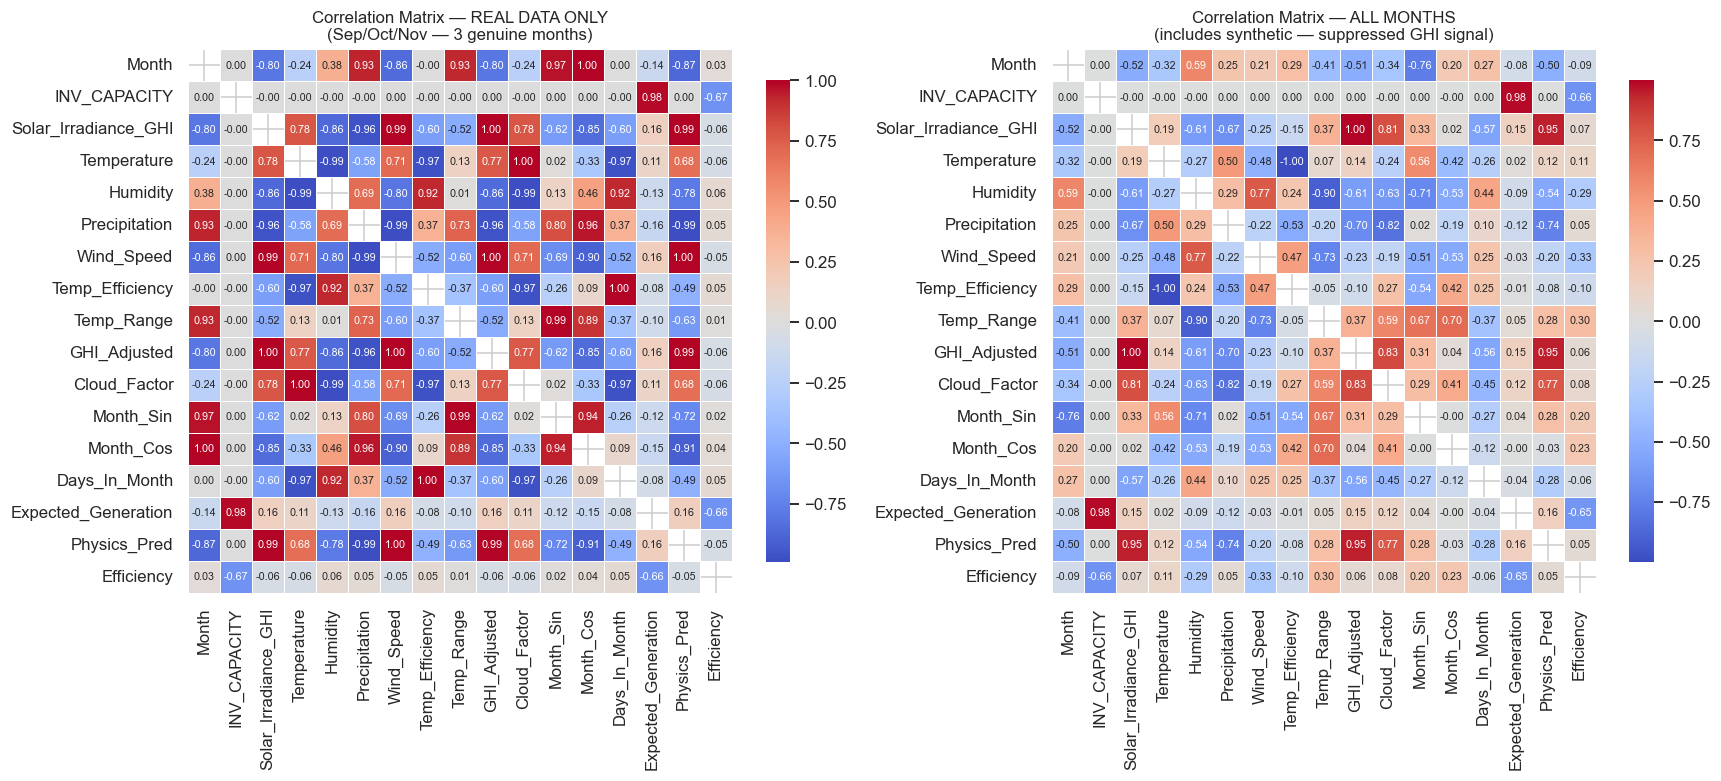

GHI <-> Efficiency correlation:
  Real months only : r = -0.057
  All months       : r = 0.066
  -> Synthetic months suppress the GHI signal. Use REAL months for correlation claims.


In [23]:
real_df = df[df['Month'].isin(REAL_M)].copy()

exclude  = {'ACCOUNT_NO','EXPORT_kWh','IMPORT_kWh','Total_Generation_kWh'}
heatmap_cols = [c for c in df.select_dtypes(include=np.number).columns
                if c not in exclude]

corr_real = real_df[heatmap_cols].corr()
corr_all  = df[heatmap_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

mask = np.zeros_like(corr_real, dtype=bool)
np.fill_diagonal(mask, True)

sns.heatmap(corr_real, ax=axes[0], annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, mask=mask,
            cbar_kws={'shrink':0.8}, annot_kws={'size':7})
axes[0].set_title('Correlation Matrix — REAL DATA ONLY\n(Sep/Oct/Nov — 3 genuine months)',
                  fontsize=11)

sns.heatmap(corr_all, ax=axes[1], annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, mask=mask,
            cbar_kws={'shrink':0.8}, annot_kws={'size':7})
axes[1].set_title('Correlation Matrix — ALL MONTHS\n(includes synthetic — suppressed GHI signal)',
                  fontsize=11)

plt.tight_layout()
plt.savefig('figures/01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("GHI <-> Efficiency correlation:")
if 'Solar_Irradiance_GHI' in heatmap_cols and 'Efficiency' in heatmap_cols:
    r_real = real_df[['Solar_Irradiance_GHI','Efficiency']].corr().iloc[0,1]
    r_all  = df[['Solar_Irradiance_GHI','Efficiency']].corr().iloc[0,1]
    print(f"  Real months only : r = {r_real:.3f}")
    print(f"  All months       : r = {r_all:.3f}")
    print("  -> Synthetic months suppress the GHI signal. Use REAL months for correlation claims.")

## 4. Engineered Feature Correlations vs Efficiency

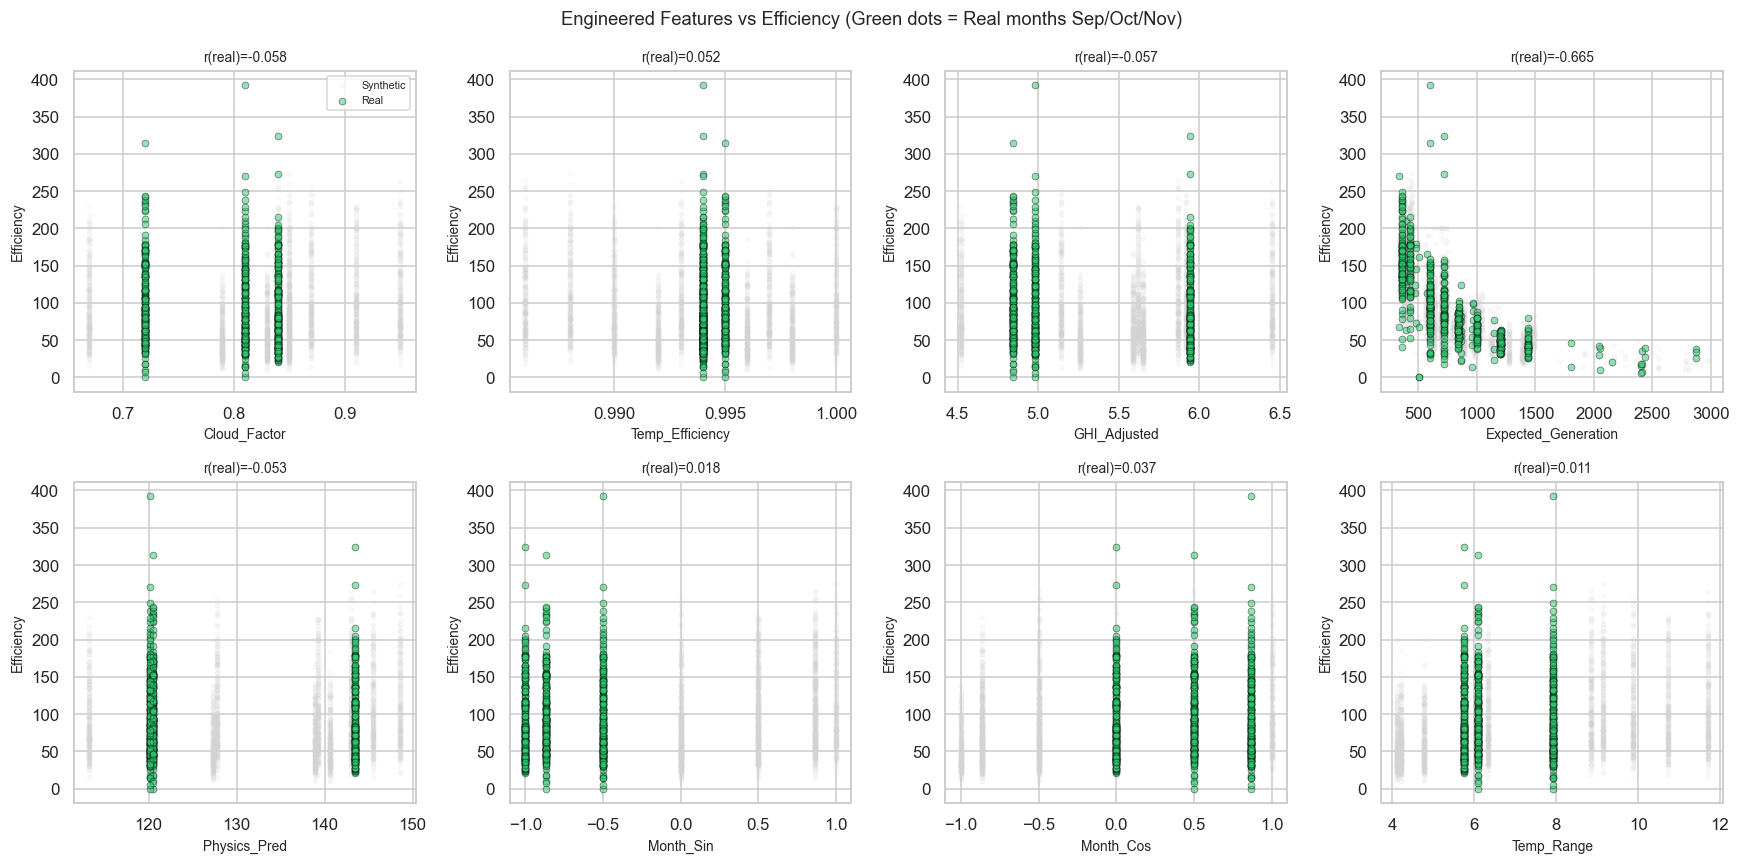

In [24]:
engineered = ['Cloud_Factor','Temp_Efficiency','GHI_Adjusted','Expected_Generation',
              'Physics_Pred','Month_Sin','Month_Cos','Temp_Range']
engineered = [c for c in engineered if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feat in zip(axes, engineered):
    real = df[df['Month'].isin(REAL_M)]
    ax.scatter(df[feat],   df['Efficiency'],   alpha=0.08, s=8,  color='lightgray', label='Synthetic')
    ax.scatter(real[feat], real['Efficiency'], alpha=0.5,  s=20, color='#2ecc71',   edgecolor='black',
               linewidth=0.5, label='Real')
    r_real, _ = pearsonr(real[feat].dropna(), real['Efficiency'][real[feat].notna()])
    ax.set_xlabel(feat, fontsize=9); ax.set_ylabel('Efficiency', fontsize=9)
    ax.set_title(f'r(real)={r_real:.3f}', fontsize=9)
    if ax == axes[0]:
        ax.legend(fontsize=7)

for ax in axes[len(engineered):]:
    ax.set_visible(False)

plt.suptitle('Engineered Features vs Efficiency (Green dots = Real months Sep/Oct/Nov)',
             fontsize=12)
plt.tight_layout()
plt.savefig('figures/01_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Efficiency vs INV_CAPACITY — Proving Normalisation Works

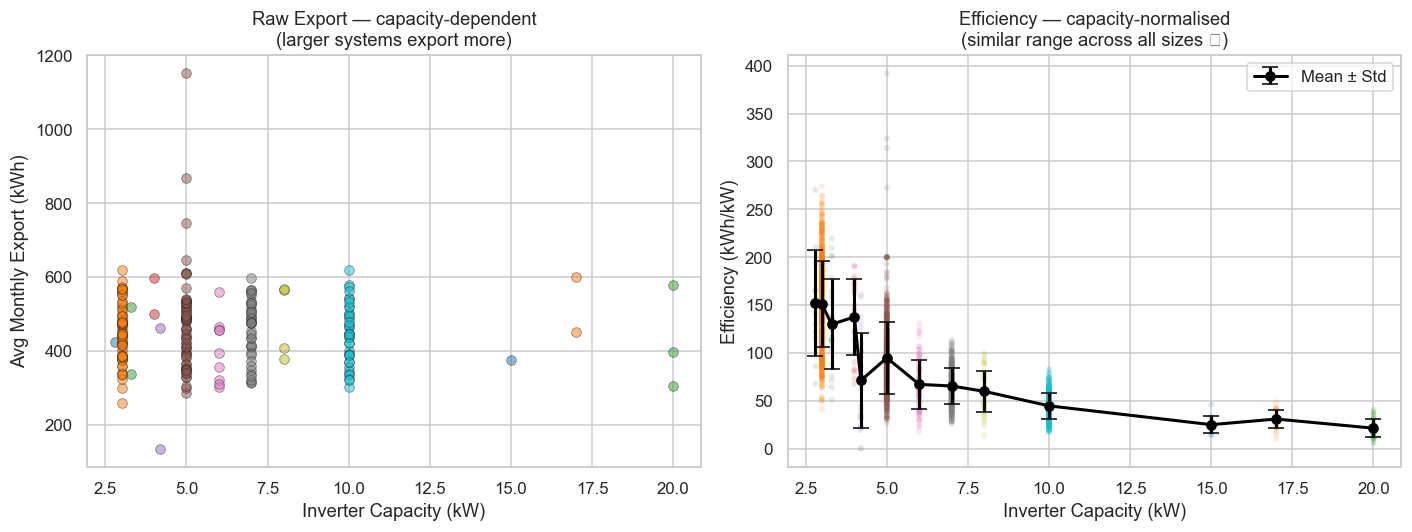

r(INV_CAPACITY, EXPORT_kWh) = -0.062  — capacity-dependent
r(INV_CAPACITY, Efficiency) = -0.663  — capacity-independent ✓


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
caps    = sorted(df['INV_CAPACITY'].unique())
palette = sns.color_palette('tab10', len(caps))

# Raw export grows with capacity
by_cap_df = solar.groupby(['ACCOUNT_NO']).agg(
    EXPORT_kWh=('EXPORT_kWh','mean'), INV_CAPACITY=('INV_CAPACITY','first')).reset_index()
for cap, col in zip(caps, palette):
    d = by_cap_df[by_cap_df['INV_CAPACITY']==cap]
    axes[0].scatter([cap]*len(d), d['EXPORT_kWh'], alpha=0.5, color=col, s=40, edgecolor='k', lw=0.5)
axes[0].set_xlabel('Inverter Capacity (kW)'); axes[0].set_ylabel('Avg Monthly Export (kWh)')
axes[0].set_title('Raw Export — capacity-dependent\n(larger systems export more)')

# Efficiency is flat across capacities
for cap, col in zip(caps, palette):
    d = df[df['INV_CAPACITY']==cap]
    axes[1].scatter([cap]*len(d), d['Efficiency'], alpha=0.15, color=col, s=15, edgecolor='none')

# Overlay mean ± std per capacity
cap_stats = df.groupby('INV_CAPACITY')['Efficiency'].agg(['mean','std'])
axes[1].errorbar(cap_stats.index, cap_stats['mean'], yerr=cap_stats['std'],
                 fmt='o-', color='black', linewidth=2, capsize=5, label='Mean ± Std')
axes[1].set_xlabel('Inverter Capacity (kW)'); axes[1].set_ylabel('Efficiency (kWh/kW)')
axes[1].set_title('Efficiency — capacity-normalised\n(similar range across all sizes ✓)')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/01_efficiency_vs_capacity.png', dpi=150, bbox_inches='tight')
plt.show()

r_raw = by_cap_df[['INV_CAPACITY','EXPORT_kWh']].corr().iloc[0,1]
r_eff = df[['INV_CAPACITY','Efficiency']].corr().iloc[0,1]
print(f"r(INV_CAPACITY, EXPORT_kWh) = {r_raw:.3f}  — capacity-dependent")
print(f"r(INV_CAPACITY, Efficiency) = {r_eff:.3f}  — capacity-independent ✓")

## 6. Physics Baseline Check

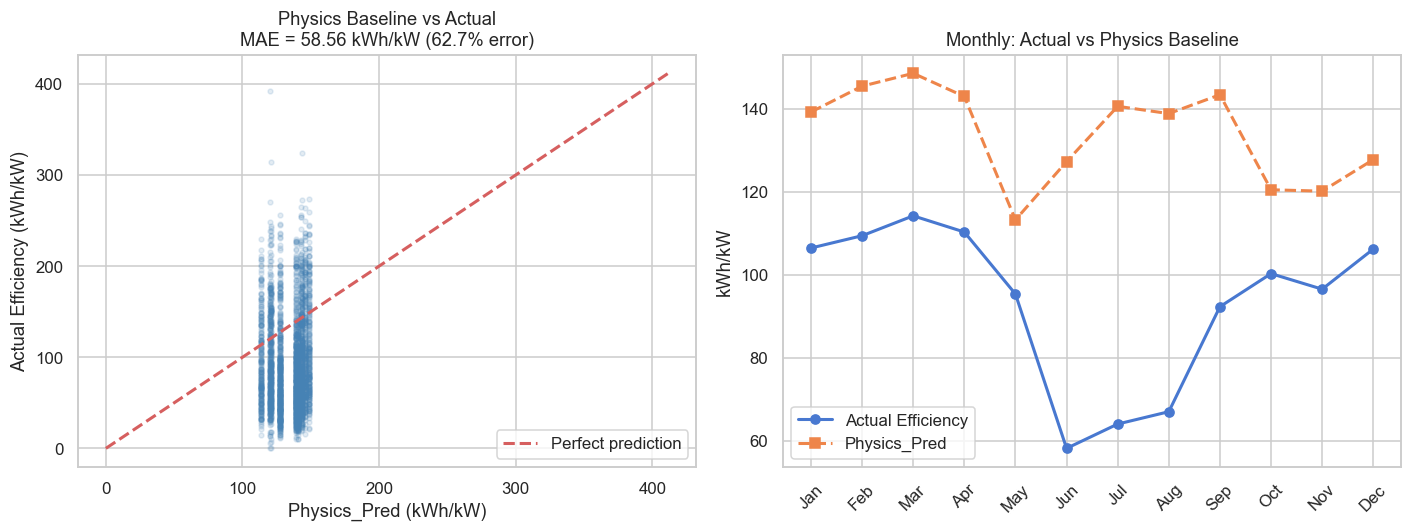

Physics MAE : 58.556 kWh/kW
Error       : 62.7% of mean Efficiency
Any ML model with MAE < this value justifies the added complexity.


In [26]:
mae_physics = mean_absolute_error(df['Efficiency'], df['Physics_Pred'])
pct_err     = mae_physics / df['Efficiency'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lim = [0, max(df['Physics_Pred'].max(), df['Efficiency'].max())*1.05]
axes[0].scatter(df['Physics_Pred'], df['Efficiency'], alpha=0.15, s=10, color='steelblue')
axes[0].plot(lim, lim, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Physics_Pred (kWh/kW)'); axes[0].set_ylabel('Actual Efficiency (kWh/kW)')
axes[0].set_title(f'Physics Baseline vs Actual\nMAE = {mae_physics:.2f} kWh/kW ({pct_err:.1f}% error)')
axes[0].legend()

monthly_eff  = df.groupby('Month')['Efficiency'].mean()
monthly_phys = df.groupby('Month')['Physics_Pred'].mean()
axes[1].plot(monthly_eff.index,  monthly_eff.values,  marker='o', linewidth=2, label='Actual Efficiency')
axes[1].plot(monthly_phys.index, monthly_phys.values, marker='s', linestyle='--', linewidth=2, label='Physics_Pred')
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(MONTHS, rotation=45)
axes[1].set_ylabel('kWh/kW'); axes[1].set_title('Monthly: Actual vs Physics Baseline')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/01_physics_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Physics MAE : {mae_physics:.3f} kWh/kW")
print(f"Error       : {pct_err:.1f}% of mean Efficiency")
print("Any ML model with MAE < this value justifies the added complexity.")